In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
sns.set_context("notebook", font_scale=1.1)

NOTEBOOK_DIR = Path('.').resolve()
PROJECT_DIR = NOTEBOOK_DIR.parent
DATA_PATH = PROJECT_DIR / "data" / "credit_risk_data.csv"
ARTIFACTS_DIR = PROJECT_DIR / "artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"NOTEBOOK_DIR: {NOTEBOOK_DIR}")
print(f"PROJECT_DIR: {PROJECT_DIR}")
print(f"DATA_PATH: {DATA_PATH}")
print(f"DATA_PATH exists: {DATA_PATH.exists()}")
print(f"ARTIFACTS_DIR: {ARTIFACTS_DIR}")

NOTEBOOK_DIR: C:\Users\kuzne\ai_engineering\project\notebooks
PROJECT_DIR: C:\Users\kuzne\ai_engineering\project
DATA_PATH: C:\Users\kuzne\ai_engineering\project\data\credit_risk_data.csv
DATA_PATH exists: True
ARTIFACTS_DIR: C:\Users\kuzne\ai_engineering\project\artifacts


In [5]:
df = pd.read_csv(DATA_PATH)

print(f"Размер датасета: {df.shape[0]} строк x {df.shape[1]} столбцов")
print(f"Использование памяти: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB\n")

print("Первые 5 строк:")
display(df.head())

print("\nТипы данных:")
display(df.dtypes)

print("\nСтатистики:")
display(df.describe())

Размер датасета: 1000 строк x 6 столбцов
Использование памяти: 0.05 MB

Первые 5 строк:


,age,income,employment_years,loan_amount,credit_score,target
0,56,135186,9,33125,319,1
1,69,64674,21,7979,823,0
2,46,65854,0,27189,828,0
3,32,76271,21,43600,446,1
4,60,103688,23,13504,603,0



Типы данных:


age                 int64
income              int64
employment_years    int64
loan_amount         int64
credit_score        int64
target              int64
dtype: object


Статистики:


,age,income,employment_years,loan_amount,credit_score,target
count,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000
mean,43.819,88926.725,11.791,24200.240,578.899,0.300
std,14.991,34764.871,7.215,14078.086,160.306,0.458
min,18.000,30060.000,0.000,1097.000,300.000,0.000
25%,31.000,58856.500,5.000,11997.250,438.750,0.000
50%,44.000,88066.500,12.000,23311.500,582.000,0.000
75%,56.000,117393.500,18.000,35622.500,717.250,1.000
max,69.000,149797.000,24.000,49998.000,849.000,1.000


In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing': missing, 'Percent': missing_pct})
missing_df = missing_df[missing_df['Missing'] > 0]

if missing_df.empty:
    print("Пропущенных значений нет")
else:
    print("Найдены пропуски:")
    display(missing_df)

duplicates = df.duplicated().sum()
print(f"\nДубликаты: {duplicates} ({duplicates/len(df)*100:.2f}%)")

print("\nУникальные значения в колонках:")
for col in df.columns:
    print(f"  {col}: {df[col].nunique()}")

quality_report = {
    'total_rows': len(df),
    'total_cols': len(df.columns),
    'missing_values': int(df.isnull().sum().sum()),
    'duplicates': int(duplicates),
    'memory_mb': round(df.memory_usage(deep=True).sum() / 1024**2, 2)
}

import json
with open(ARTIFACTS_DIR / 'data_quality_report.json', 'w') as f:
    json.dump(quality_report, f, indent=2)

print(f"\nОтчёт сохранён: {ARTIFACTS_DIR / 'data_quality_report.json'}")

Пропущенных значений нет

Дубликаты: 0 (0.00%)

Уникальные значения в колонках:
  age: 52
  income: 996
  employment_years: 25
  loan_amount: 992
  credit_score: 458
  target: 2

Отчёт сохранён: C:\Users\kuzne\ai_engineering\project\artifacts\data_quality_report.json


Распределение target:
  Класс 0 (низкий риск): 700 (70.0%)
  Класс 1 (высокий риск): 300 (30.0%)
  Дисбаланс: 2.33x


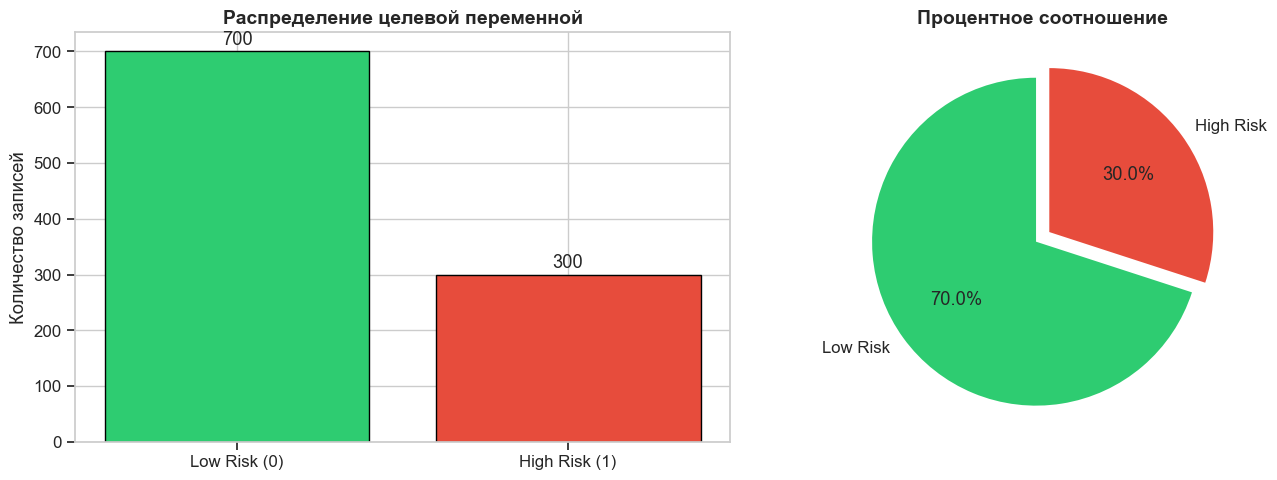

График сохранён: C:\Users\kuzne\ai_engineering\project\artifacts\eda_target_distribution.png


In [7]:
target_counts = df['target'].value_counts()
target_pct = df['target'].value_counts(normalize=True) * 100

print("Распределение target:")
print(f"  Класс 0 (низкий риск): {target_counts[0]} ({target_pct[0]:.1f}%)")
print(f"  Класс 1 (высокий риск): {target_counts[1]} ({target_pct[1]:.1f}%)")
print(f"  Дисбаланс: {target_counts[0]/target_counts[1]:.2f}x")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(['Low Risk (0)', 'High Risk (1)'], target_counts.values, 
                   color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Распределение целевой переменной', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Количество записей')
for bar, val in zip(bars, target_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
                str(val), ha='center', va='bottom')

axes[1].pie(target_counts.values, labels=['Low Risk', 'High Risk'], 
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], 
            explode=(0.05, 0.05), startangle=90)
axes[1].set_title('Процентное соотношение', fontsize=14, fontweight='bold')

plt.tight_layout()
output_path = ARTIFACTS_DIR / 'eda_target_distribution.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"График сохранён: {output_path}")

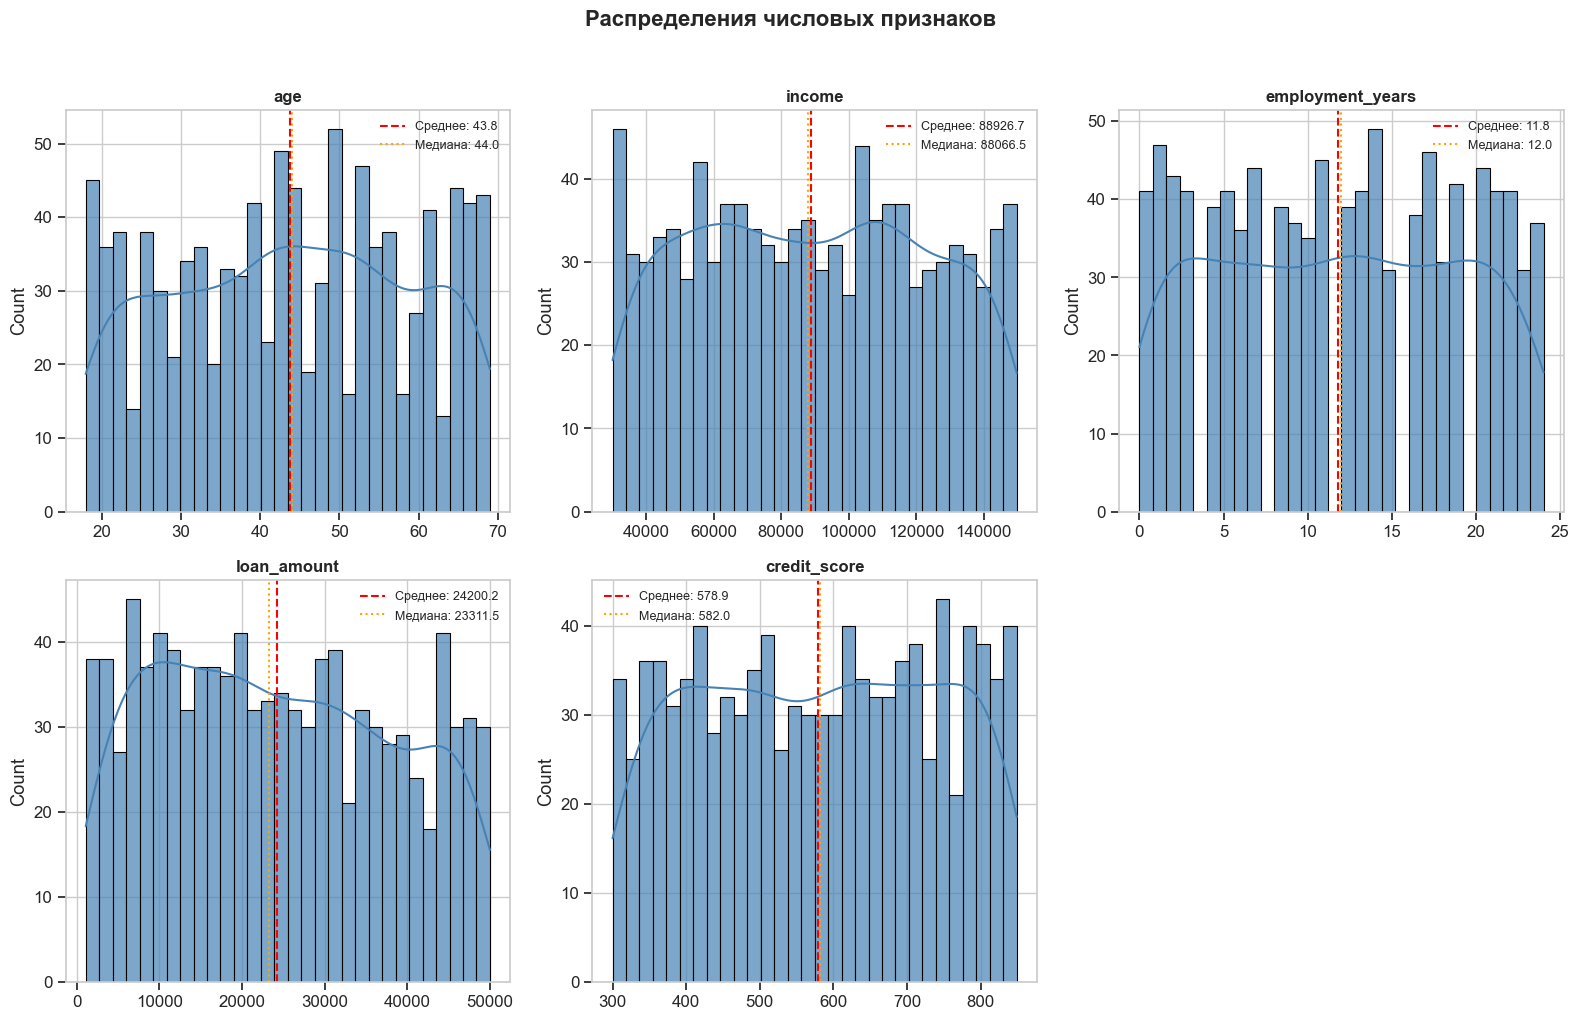

График сохранён: C:\Users\kuzne\ai_engineering\project\artifacts\eda_numeric_distributions.png

Статистики признаков:

age:
  Мин: 18
  Макс: 69
  Среднее: 43.8
  Медиана: 44.0
  Std: 15.0

income:
  Мин: 30,060
  Макс: 149,797
  Среднее: 88,926.7
  Медиана: 88,066.5
  Std: 34,764.9

employment_years:
  Мин: 0
  Макс: 24
  Среднее: 11.8
  Медиана: 12.0
  Std: 7.2

loan_amount:
  Мин: 1,097
  Макс: 49,998
  Среднее: 24,200.2
  Медиана: 23,311.5
  Std: 14,078.1

credit_score:
  Мин: 300
  Макс: 849
  Среднее: 578.9
  Медиана: 582.0
  Std: 160.3


In [8]:
numeric_cols = ['age', 'income', 'employment_years', 'loan_amount', 'credit_score']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    sns.histplot(data=df, x=col, bins=30, kde=True, ax=axes[idx], 
                 color='steelblue', edgecolor='black', alpha=0.7)
    
    mean_val = df[col].mean()
    median_val = df[col].median()
    axes[idx].axvline(mean_val, color='red', linestyle='--', label=f'Среднее: {mean_val:.1f}')
    axes[idx].axvline(median_val, color='orange', linestyle=':', label=f'Медиана: {median_val:.1f}')
    
    axes[idx].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes[idx].legend(fontsize=9)
    axes[idx].set_xlabel('')

axes[5].axis('off')

plt.suptitle('Распределения числовых признаков', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
output_path = ARTIFACTS_DIR / 'eda_numeric_distributions.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"График сохранён: {output_path}")

print("\nСтатистики признаков:")
for col in numeric_cols:
    print(f"\n{col}:")
    print(f"  Мин: {df[col].min():,}")
    print(f"  Макс: {df[col].max():,}")
    print(f"  Среднее: {df[col].mean():,.1f}")
    print(f"  Медиана: {df[col].median():,.1f}")
    print(f"  Std: {df[col].std():,.1f}")

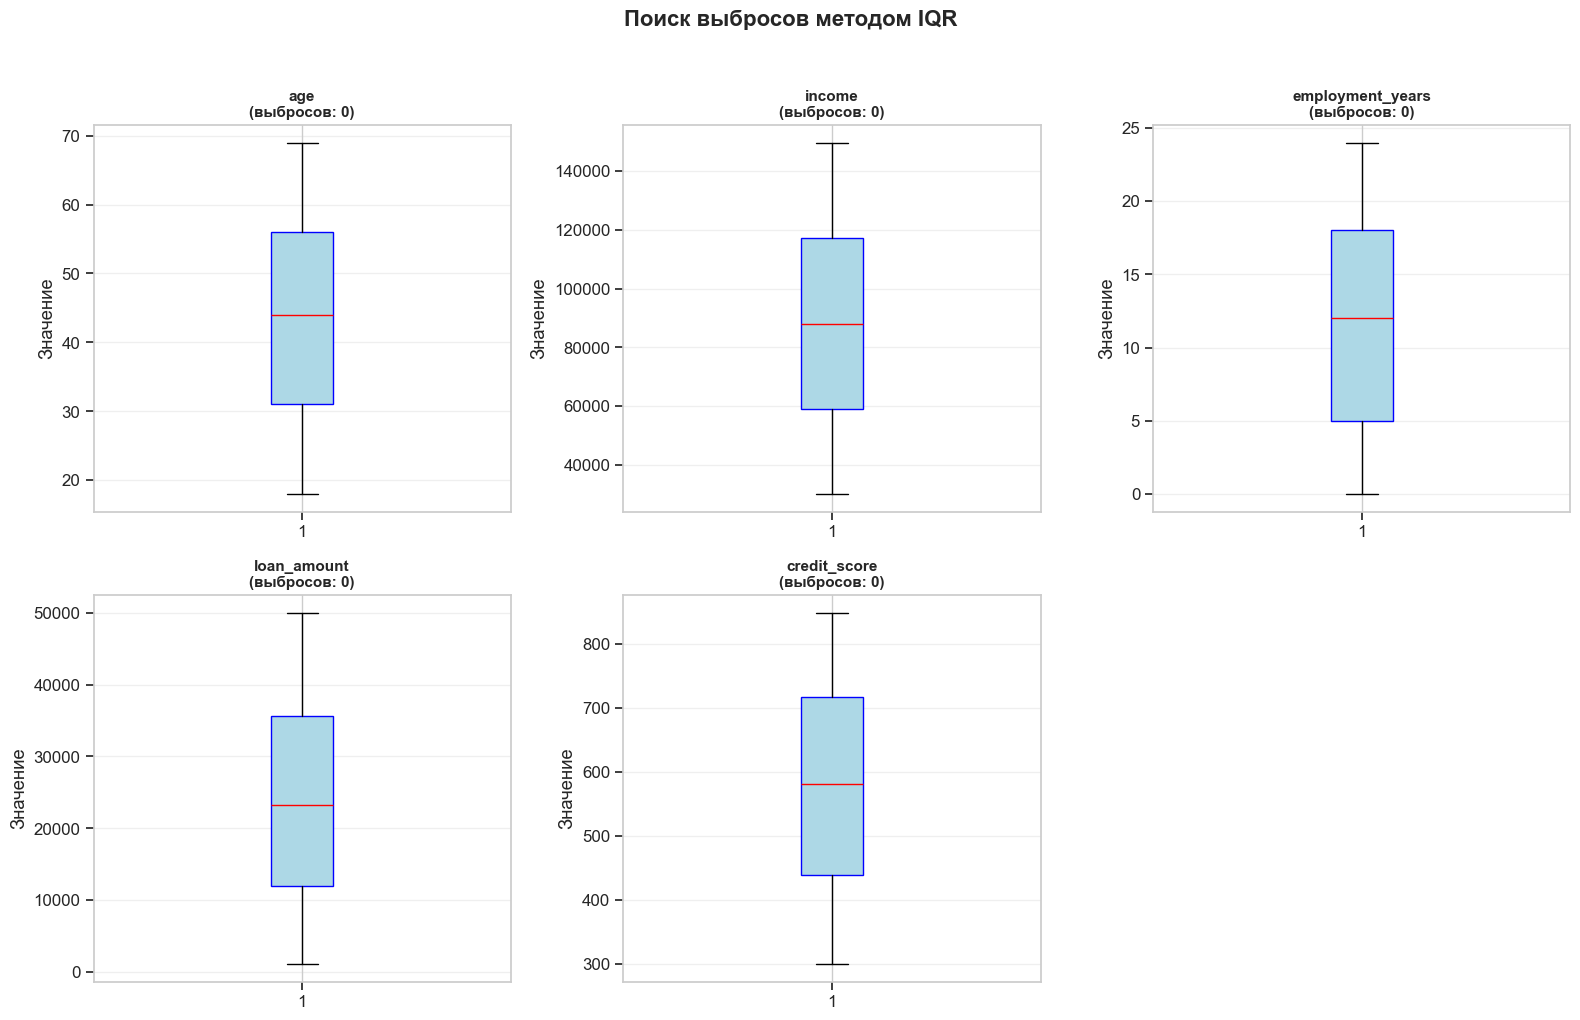

График сохранён: C:\Users\kuzne\ai_engineering\project\artifacts\eda_boxplots_outliers.png

Выбросы по признакам (метод IQR):


,feature,outliers,outlier_pct,lower_bound,upper_bound
0,age,0,0.00%,-6,94
1,income,0,0.00%,"-28,949","205,199"
2,employment_years,0,0.00%,-14,38
3,loan_amount,0,0.00%,"-23,441","71,060"
4,credit_score,0,0.00%,21,"1,135"


In [9]:
def count_outliers_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    return len(outliers), lower_bound, upper_bound

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

outlier_summary = []

for idx, col in enumerate(numeric_cols):
    n_outliers, lower, upper = count_outliers_iqr(df[col])
    outlier_summary.append({
        'feature': col,
        'outliers': n_outliers,
        'outlier_pct': n_outliers / len(df) * 100,
        'lower_bound': lower,
        'upper_bound': upper
    })
    
    bp = axes[idx].boxplot(df[col], vert=True, patch_artist=True, 
                           boxprops=dict(facecolor='lightblue', color='blue'),
                           medianprops=dict(color='red'),
                           flierprops=dict(marker='o', markerfacecolor='red', 
                                          markersize=4, linestyle='none'))
    
    axes[idx].set_title(f'{col}\n(выбросов: {n_outliers})', 
                       fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Значение')
    axes[idx].grid(axis='y', alpha=0.3)

axes[5].axis('off')
plt.suptitle('Поиск выбросов методом IQR', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
output_path = ARTIFACTS_DIR / 'eda_boxplots_outliers.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"График сохранён: {output_path}")

print("\nВыбросы по признакам (метод IQR):")
outlier_df = pd.DataFrame(outlier_summary)
display(outlier_df.style.format({'outlier_pct': '{:.2f}%', 'lower_bound': '{:,.0f}', 'upper_bound': '{:,.0f}'}))

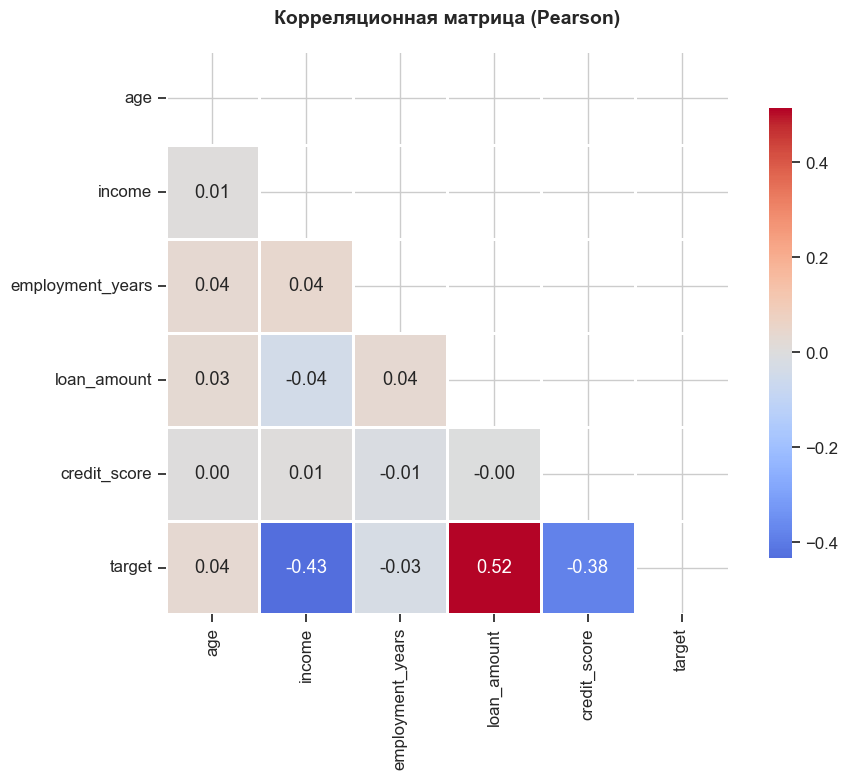

График сохранён: C:\Users\kuzne\ai_engineering\project\artifacts\eda_correlation_matrix.png

Корреляция признаков с целевой переменной target:
  + loan_amount: +0.515 (сильная)
  + age: +0.037 (слабая)
  - employment_years: -0.026 (слабая)
  - credit_score: -0.385 (умеренная)
  - income: -0.433 (умеренная)


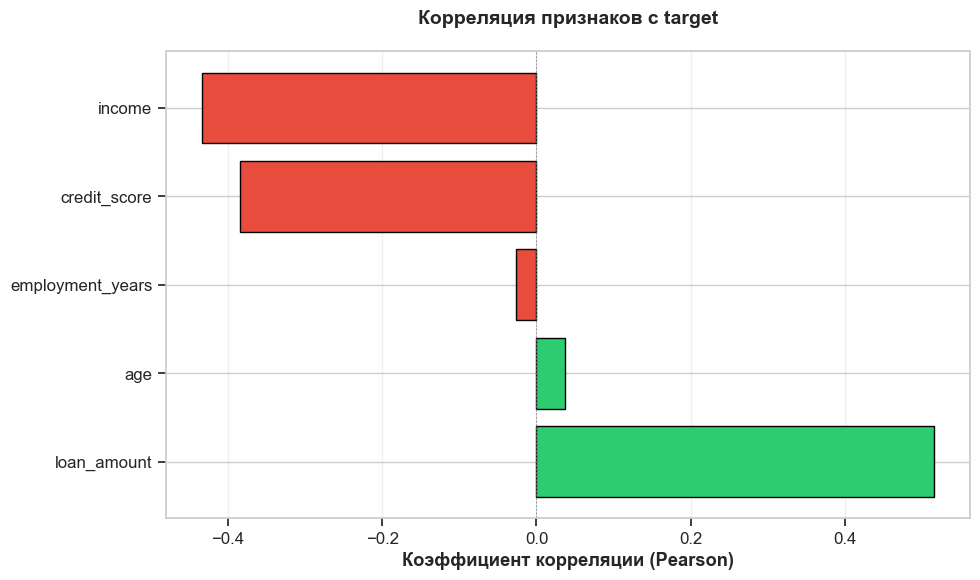

График сохранён: C:\Users\kuzne\ai_engineering\project\artifacts\eda_target_correlation.png


In [10]:
plt.figure(figsize=(10, 8))
corr_matrix = df.corr(method='pearson')

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Корреляционная матрица (Pearson)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
output_path = ARTIFACTS_DIR / 'eda_correlation_matrix.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"График сохранён: {output_path}")

target_corr = df.corr()['target'].drop('target').sort_values(ascending=False)

print("\nКорреляция признаков с целевой переменной target:")
for feat, corr_val in target_corr.items():
    if abs(corr_val) > 0.5:
        strength = 'сильная'
    elif abs(corr_val) > 0.3:
        strength = 'умеренная'
    else:
        strength = 'слабая'
    direction = '+' if corr_val > 0 else '-'
    print(f"  {direction} {feat}: {corr_val:+.3f} ({strength})")

plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in target_corr.values]
bars = plt.barh(target_corr.index, target_corr.values, color=colors, edgecolor='black')
plt.xlabel('Коэффициент корреляции (Pearson)', fontweight='bold')
plt.title('Корреляция признаков с target', fontsize=14, fontweight='bold', pad=20)
plt.axvline(x=0, color='gray', linestyle='--', linewidth=0.5)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
output_path = ARTIFACTS_DIR / 'eda_target_correlation.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"График сохранён: {output_path}")

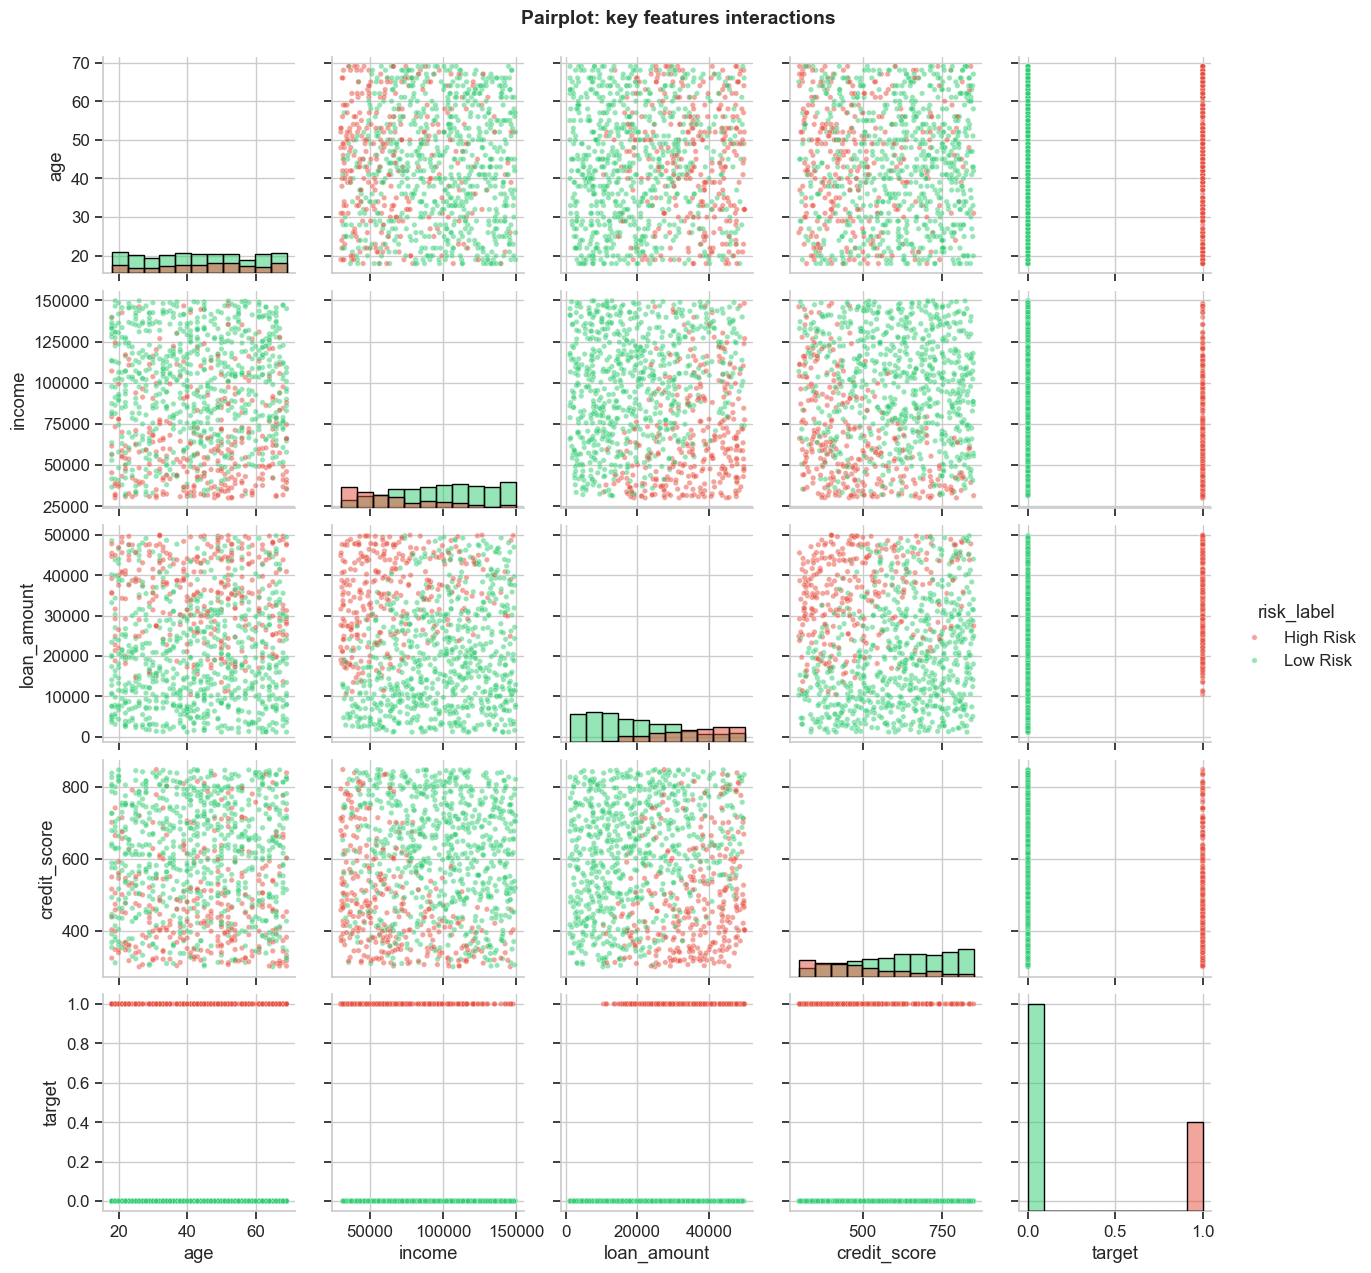

Saved: C:\Users\kuzne\ai_engineering\project\artifacts\eda_pairplot_key_features.png


In [11]:
plot_cols = ['age', 'income', 'loan_amount', 'credit_score', 'target']
plot_df = df[plot_cols].copy()

plot_df['risk_label'] = plot_df['target'].map({0: 'Low Risk', 1: 'High Risk'})

sns.pairplot(plot_df, hue='risk_label', palette={'Low Risk': '#2ecc71', 'High Risk': '#e74c3c'},
             plot_kws={'alpha': 0.5, 's': 15}, diag_kind='hist', height=2.5)
plt.suptitle('Pairplot: key features interactions', y=1.02, fontsize=14, fontweight='bold')
output_path = ARTIFACTS_DIR / 'eda_pairplot_key_features.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {output_path}")

In [12]:
from datetime import datetime

eda_summary = {
    'timestamp': datetime.now().isoformat(),
    'dataset': {
        'rows': len(df),
        'columns': len(df.columns),
        'memory_mb': round(df.memory_usage(deep=True).sum() / 1024**2, 2)
    },
    'quality': {
        'missing_values': int(df.isnull().sum().sum()),
        'duplicates': int(df.duplicated().sum())
    },
    'target': {
        'class_0_count': int(target_counts[0]),
        'class_1_count': int(target_counts[1]),
        'class_0_pct': round(target_pct[0], 1),
        'class_1_pct': round(target_pct[1], 1),
        'imbalance_ratio': round(target_counts[0]/target_counts[1], 2)
    },
    'outliers': {row['feature']: int(row['outliers']) for _, row in outlier_df.iterrows()},
    'top_correlations_with_target': {feat: round(val, 3) for feat, val in target_corr.head(3).items()},
    'artifacts_saved': [f.name for f in ARTIFACTS_DIR.glob('*.png')] + 
                       [f.name for f in ARTIFACTS_DIR.glob('*.json')]
}

import json
with open(ARTIFACTS_DIR / 'eda_summary_report.json', 'w', encoding='utf-8') as f:
    json.dump(eda_summary, f, indent=2, ensure_ascii=False)

print("Итоговый отчёт EDA:")
print(json.dumps(eda_summary, indent=2, ensure_ascii=False))
print(f"\nСохранён: {ARTIFACTS_DIR / 'eda_summary_report.json'}")

Итоговый отчёт EDA:
{
  "timestamp": "2026-05-21T14:54:41.696274",
  "dataset": {
    "rows": 1000,
    "columns": 6,
    "memory_mb": 0.05
  },
  "quality": {
    "missing_values": 0,
    "duplicates": 0
  },
  "target": {
    "class_0_count": 700,
    "class_1_count": 300,
    "class_0_pct": 70.0,
    "class_1_pct": 30.0,
    "imbalance_ratio": 2.33
  },
  "outliers": {
    "age": 0,
    "income": 0,
    "employment_years": 0,
    "loan_amount": 0,
    "credit_score": 0
  },
  "top_correlations_with_target": {
    "loan_amount": 0.515,
    "age": 0.037,
    "employment_years": -0.026
  },
  "artifacts_saved": [
    "correlation_matrix.png",
    "eda_boxplots_outliers.png",
    "eda_correlation_matrix.png",
    "eda_numeric_distributions.png",
    "eda_pairplot_key_features.png",
    "eda_target_correlation.png",
    "eda_target_distribution.png",
    "target_distribution.png",
    "data_quality_report.json"
  ]
}

Сохранён: C:\Users\kuzne\ai_engineering\project\artifacts\eda_summary_

### Качество данных
- Датасет чистый: нет пропусков, дубликатов и выбросов
- 1000 записей, 6 признаков (5 числовых + 1 целевой)
- Все признаки в разумных диапазонах

### Распределение целевой переменной
- Класс 0 (низкий риск): 70% (700 записей)
- Класс 1 (высокий риск): 30% (300 записей)
- Дисбаланс 2.33x - умеренный, потребуется StratifiedKFold

### Ключевые инсайты по корреляциям
1. **loan_amount**: +0.515 (сильная положительная)
   - Чем больше сумма кредита, тем выше риск дефолта

2. **income**: -0.433 (умеренная отрицательная)
   - Чем выше доход, тем ниже риск

3. **credit_score**: -0.385 (умеренная отрицательная)
   - Чем выше кредитный рейтинг, тем ниже риск

4. **age**: +0.037 (очень слабая)
   - Возраст практически не влияет на риск

5. **employment_years**: -0.026 (очень слабая)
   - Стаж работы слабо коррелирует с риском
